# Projeto Detecção de Fraude em Cartões de Crédito

## Importando bibliotecas auxiliares

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from google.colab import drive
from imblearn.over_sampling import SMOTE

## Montando o drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


## Lendo o dataframe com os dados do cartão de crédito

In [ ]:
caminho_arquivo = '/content/drive/MyDrive/creditcard.csv'

try:
    df = pd.read_csv(caminho_arquivo)
except FileNotFoundError:
    caminho_arquivo = '/content/drive/MyDrive/Projeto_Eixo5/creditcard.csv'
    df = pd.read_csv(caminho_arquivo)

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Criando escala

In [ ]:
scaler = StandardScaler()

## Normalizando coluna Amount

In [ ]:
df["Normalized_Amount"] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))

## Removendo colunas Time e Amount

In [ ]:
df=df.drop(columns=['Time',"Amount"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   V1                 284807 non-null  float64
 1   V2                 284807 non-null  float64
 2   V3                 284807 non-null  float64
 3   V4                 284807 non-null  float64
 4   V5                 284807 non-null  float64
 5   V6                 284807 non-null  float64
 6   V7                 284807 non-null  float64
 7   V8                 284807 non-null  float64
 8   V9                 284807 non-null  float64
 9   V10                284807 non-null  float64
 10  V11                284807 non-null  float64
 11  V12                284807 non-null  float64
 12  V13                284807 non-null  float64
 13  V14                284807 non-null  float64
 14  V15                284807 non-null  float64
 15  V16                284807 non-null  float64
 16  V1

## Verificando nulos

In [ ]:
df.isna().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


## Verificando duplicatas

In [ ]:
df.duplicated().sum()

np.int64(9144)

## Calculando o número de fraudes e transações genuinas

In [ ]:
transacao_genuina = df[df['Class']==0].shape[0]
transacao_fraudulenta = df[df['Class'] == 1].shape[0]

print(f'total_transacoes_genuinas: {transacao_genuina}')
print(f'total_transacoes_fraudulentas: {transacao_fraudulenta}')

total_transacoes_genuinas: 284315
total_transacoes_fraudulentas: 492


In [ ]:
porcentagem_de_fraudes =(transacao_fraudulenta/df.shape[0])*100

print(f'porcentagem_de_fraudes: {porcentagem_de_fraudes}')

porcentagem_de_fraudes: 0.1727485630620034


In [ ]:
df['Class'].value_counts(normalize=True)*100

,proportion
Class,
0,99.827251
1,0.172749


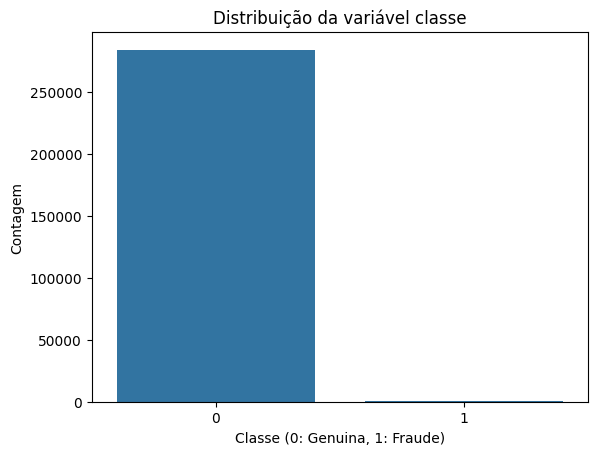

In [ ]:
sns.countplot(x='Class', data=df)
plt.title("Distribuição da variável classe")
plt.xlabel('Classe (0: Genuina, 1: Fraude)')
plt.ylabel('Contagem')
plt.show()

([<matplotlib.patches.Wedge at 0x7b32cb1f1fd0>,
 [Text(-1.0999838024749575, 0.0059694466019511215, 'Genuina'),
  Text(1.099983802996819, -0.005969350438309128, 'Fraude')],
 [Text(-0.5999911649863404, 0.0032560617828824297, '99.83%'),
  Text(0.5999911652709922, -0.0032560093299867964, '0.17%')])

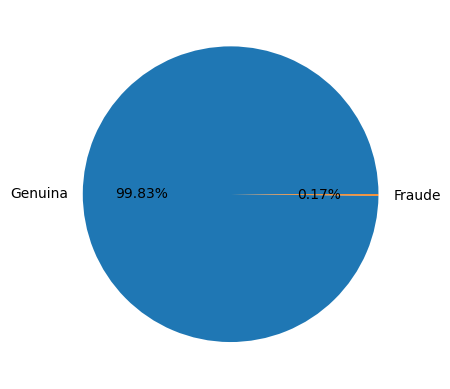

In [ ]:
plt.pie(df['Class'].value_counts(),labels=['Genuina','Fraude'],autopct="%1.2f%%")

## Utilizando o SMOTE

In [ ]:
smote = SMOTE(random_state=42)